# 🏅 Data Lake — Jogos Olímpicos

Este notebook implementa um Data Lake local com dados históricos dos Jogos Olímpicos (1896–2022) e Paris 2024.

**Etapas:**
1. Criação da estrutura de diretórios do Data Lake
2. Camada `raw/` — dados brutos + metadados JSON
3. Camada `bronze/` — conversão para Parquet + integração (JOINs)
4. Camada `gold/` — quadro de medalhas final + visualizações

---
- **Aluno:** Daniel Nazário Oliveira de Souza
- **Professor:** Luis Cueves Rodriguez

## 0. Instalações e Imports

In [ ]:
# Instalar dependências necessárias
!pip install pyarrow fastparquet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os
import json
import shutil
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import date
from IPython.display import display, HTML

print("✅ Imports realizados com sucesso!")

✅ Imports realizados com sucesso!


## 1. Upload dos Arquivos CSV

Faça o upload dos dois arquivos:
- `world_olympedia_olympics_game_medal_tally.csv` (histórico 1896–2022)
- `medals_total.csv` (Paris 2024)

In [ ]:
from google.colab import files

print("Faça o upload dos dois arquivos CSV:")
uploaded = files.upload()

print("\nArquivos recebidos:")
for nome in uploaded.keys():
    print(f"  ✅ {nome}")

Faça o upload dos dois arquivos CSV:


Saving medals_total.csv to medals_total.csv

Arquivos recebidos:
  ✅ medals_total.csv


## 2. Criação da Estrutura de Diretórios do Data Lake

In [ ]:
# Definir raiz do Data Lake
DATALAKE_ROOT = Path("olympics-datalake")

# Estrutura completa de diretórios conforme especificação
diretorios = [
    DATALAKE_ROOT / "raw",
    DATALAKE_ROOT / "bronze",
    DATALAKE_ROOT / "gold" / "analise_medalhas",
    DATALAKE_ROOT / "gold" / "analise_modalidades",
    DATALAKE_ROOT / "gold" / "analise_genero",
]

for diretorio in diretorios:
    diretorio.mkdir(parents=True, exist_ok=True)

print("✅ Estrutura de diretórios criada:")
for root, dirs, files_list in os.walk(DATALAKE_ROOT):
    nivel = root.replace(str(DATALAKE_ROOT), '').count(os.sep)
    indent = '│   ' * nivel + '├── '
    print(f"{indent}{os.path.basename(root)}/")

✅ Estrutura de diretórios criada:
├── olympics-datalake/
│   ├── bronze/
│   ├── raw/
│   ├── gold/
│   │   ├── analise_modalidades/
│   │   ├── analise_medalhas/
│   │   ├── analise_genero/


## 3. Camada RAW — Dados Brutos + Metadados JSON

In [ ]:
# Nomes dos arquivos de origem (conforme feito upload)
ARQUIVO_HISTORICO_ORIGEM = "world_olympedia_olympics_game_medal_tally.csv"
ARQUIVO_PARIS_ORIGEM     = "medals_total.csv"

# Caminhos de destino na camada raw
RAW_HISTORICO = DATALAKE_ROOT / "raw" / "olympics_historico.csv"
RAW_PARIS     = DATALAKE_ROOT / "raw" / "olympics_paris2024.csv"

# Copiar arquivos brutos para a pasta raw/
shutil.copy(ARQUIVO_HISTORICO_ORIGEM, RAW_HISTORICO)
shutil.copy(ARQUIVO_PARIS_ORIGEM,     RAW_PARIS)

print(f"✅ Arquivos copiados para raw/:")
print(f"   {RAW_HISTORICO}")
print(f"   {RAW_PARIS}")

✅ Arquivos copiados para raw/:
   olympics-datalake/raw/olympics_historico.csv
   olympics-datalake/raw/olympics_paris2024.csv


In [ ]:
# Carregar os dados para inspecionar antes de criar os metadados
df_hist = pd.read_csv(RAW_HISTORICO)
df_p24  = pd.read_csv(RAW_PARIS)

print("=== Histórico ===")
print(f"Shape: {df_hist.shape}")
print(f"Colunas: {df_hist.columns.tolist()}")
print(df_hist.head(3))

print("\n=== Paris 2024 ===")
print(f"Shape: {df_p24.shape}")
print(f"Colunas: {df_p24.columns.tolist()}")
print(df_p24.head(3))

=== Histórico ===
Shape: (1807, 9)
Colunas: ['year', 'edition', 'edition_id', 'country', 'country_noc', 'gold', 'silver', 'bronze', 'total']
   year               edition  edition_id        country country_noc  gold  \
0  1896  1896 Summer Olympics           1         Greece         GRE    10   
1  1900  1900 Summer Olympics           2         France         FRA    31   
2  1900  1900 Summer Olympics           2  United States         USA    20   

   silver  bronze  total  
0      18      19     47  
1      41      40    112  
2      13      15     48  

=== Paris 2024 ===
Shape: (92, 7)
Colunas: ['country_code', 'country', 'country_long', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']
  country_code        country                country_long  Gold Medal  \
0          USA  United States    United States of America          40   
1          CHN          China  People's Republic of China          40   
2          JPN          Japan                       Japan          20   

  

In [ ]:
# -------------------------------------------------------
# Metadados — olympics_historico.csv
# -------------------------------------------------------
meta_historico = {
    "nome_dataset": "olympics_historico",
    "fonte": "Base dos Dados / Olympedia (https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b)",
    "descricao": "Quadro histórico de medalhas por país e por edição dos Jogos Olímpicos de 1896 a 2022, incluindo Jogos de Verão e Inverno.",
    "campos_principais": [
        {"nome": "year",        "tipo": "int",    "descricao": "Ano da edição dos Jogos"},
        {"nome": "edition",     "tipo": "string",  "descricao": "Nome completo da edição (ex: 1896 Summer Olympics)"},
        {"nome": "edition_id",  "tipo": "int",    "descricao": "Identificador numérico da edição"},
        {"nome": "country",     "tipo": "string",  "descricao": "Nome completo do país"},
        {"nome": "country_noc", "tipo": "string",  "descricao": "Código NOC de 3 letras do país"},
        {"nome": "gold",        "tipo": "int",    "descricao": "Total de medalhas de ouro"},
        {"nome": "silver",      "tipo": "int",    "descricao": "Total de medalhas de prata"},
        {"nome": "bronze",      "tipo": "int",    "descricao": "Total de medalhas de bronze"},
        {"nome": "total",       "tipo": "int",    "descricao": "Soma total de medalhas"}
    ],
    "formato": "CSV",
    "delimitador": ",",
    "codificacao": "utf-8",
    "quantidade_linhas": len(df_hist),
    "quantidade_colunas": len(df_hist.columns),
    "periodo_coberto": "1896–2022",
    "data_coleta": str(date.today()),
    "camada": "raw",
    "caminho": str(RAW_HISTORICO),
    "observacoes": "A temporada (Verão/Inverno) é inferida a partir da coluna 'edition'. Dados já agregados por país por edição.",
    "versao": "1.0"
}

# Salvar metadados
caminho_meta_hist = DATALAKE_ROOT / "raw" / "olympics_historico.json"
with open(caminho_meta_hist, "w", encoding="utf-8") as f:
    json.dump(meta_historico, f, ensure_ascii=False, indent=4)

print(f"✅ Metadados salvos: {caminho_meta_hist}")

✅ Metadados salvos: olympics-datalake/raw/olympics_historico.json


In [ ]:
# -------------------------------------------------------
# Metadados — olympics_paris2024.csv
# -------------------------------------------------------
meta_paris = {
    "nome_dataset": "olympics_paris2024",
    "fonte": "Kaggle — Paris 2024 Olympic Summer Games (https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games)",
    "descricao": "Quadro de medalhas dos Jogos Olímpicos de Paris 2024, com totais por país.",
    "campos_principais": [
        {"nome": "country_code",  "tipo": "string", "descricao": "Código NOC de 3 letras do país"},
        {"nome": "country",       "tipo": "string", "descricao": "Nome abreviado do país"},
        {"nome": "country_long",  "tipo": "string", "descricao": "Nome completo do país"},
        {"nome": "Gold Medal",    "tipo": "int",   "descricao": "Total de medalhas de ouro"},
        {"nome": "Silver Medal",  "tipo": "int",   "descricao": "Total de medalhas de prata"},
        {"nome": "Bronze Medal",  "tipo": "int",   "descricao": "Total de medalhas de bronze"},
        {"nome": "Total",         "tipo": "int",   "descricao": "Soma total de medalhas"}
    ],
    "formato": "CSV",
    "delimitador": ",",
    "codificacao": "utf-8",
    "quantidade_linhas": len(df_p24),
    "quantidade_colunas": len(df_p24.columns),
    "periodo_coberto": "2024 (Paris)",
    "data_coleta": str(date.today()),
    "camada": "raw",
    "caminho": str(RAW_PARIS),
    "observacoes": "Contém apenas Jogos de Verão. Deve ser integrado ao histórico para análise completa.",
    "versao": "1.0"
}

# Salvar metadados
caminho_meta_paris = DATALAKE_ROOT / "raw" / "olympics_paris2024.json"
with open(caminho_meta_paris, "w", encoding="utf-8") as f:
    json.dump(meta_paris, f, ensure_ascii=False, indent=4)

print(f"✅ Metadados salvos: {caminho_meta_paris}")

✅ Metadados salvos: olympics-datalake/raw/olympics_paris2024.json


## 4. Camada BRONZE — Conversão para Parquet + Integração (JOIN)

In [ ]:
# -------------------------------------------------------
# 4.1 Padronizar e converter histórico para Parquet
# -------------------------------------------------------

# Inferir temporada a partir da coluna 'edition'
df_hist['season'] = df_hist['edition'].apply(
    lambda x: 'Winter' if 'Winter' in str(x) else 'Summer'
)

# Renomear colunas para padrão consistente
df_hist = df_hist.rename(columns={
    'country_noc': 'NOC',
    'country':     'country_name',
    'gold':        'Gold',
    'silver':      'Silver',
    'bronze':      'Bronze',
    'total':       'Total'
})

print("✅ Histórico padronizado:")
print(df_hist.dtypes)
print(df_hist.head(3))

✅ Histórico padronizado:
year             int64
edition         object
edition_id       int64
country_name    object
NOC             object
Gold             int64
Silver           int64
Bronze           int64
Total            int64
season          object
dtype: object
   year               edition  edition_id   country_name  NOC  Gold  Silver  \
0  1896  1896 Summer Olympics           1         Greece  GRE    10      18   
1  1900  1900 Summer Olympics           2         France  FRA    31      41   
2  1900  1900 Summer Olympics           2  United States  USA    20      13   

   Bronze  Total  season  
0      19     47  Summer  
1      40    112  Summer  
2      15     48  Summer  


In [ ]:
# -------------------------------------------------------
# 4.2 Padronizar Paris 2024 para Parquet
# -------------------------------------------------------
df_p24 = df_p24.rename(columns={
    'country_code': 'NOC',
    'country_long': 'country_name',
    'Gold Medal':   'Gold',
    'Silver Medal': 'Silver',
    'Bronze Medal': 'Bronze'
})

# Adicionar colunas de contexto
df_p24['year']   = 2024
df_p24['edition'] = '2024 Summer Olympics'
df_p24['season']  = 'Summer'
df_p24['edition_id'] = 0  # Paris 2024 não tem edition_id no histórico

# Manter apenas colunas que existem no histórico
colunas_padrao = ['year', 'edition', 'edition_id', 'country_name', 'NOC', 'Gold', 'Silver', 'Bronze', 'Total', 'season']
df_p24 = df_p24[colunas_padrao]

print("✅ Paris 2024 padronizado:")
print(df_p24.head(5))

✅ Paris 2024 padronizado:
   year               edition  edition_id                country_name  NOC  \
0  2024  2024 Summer Olympics           0    United States of America  USA   
1  2024  2024 Summer Olympics           0  People's Republic of China  CHN   
2  2024  2024 Summer Olympics           0                       Japan  JPN   
3  2024  2024 Summer Olympics           0                   Australia  AUS   
4  2024  2024 Summer Olympics           0                      France  FRA   

   Gold  Silver  Bronze  Total  season  
0    40      44      42    126  Summer  
1    40      27      24     91  Summer  
2    20      12      13     45  Summer  
3    18      19      16     53  Summer  
4    16      26      22     64  Summer  


In [ ]:
# -------------------------------------------------------
# 4.3 Salvar arquivos individuais em Parquet na bronze/
# -------------------------------------------------------
BRONZE = DATALAKE_ROOT / "bronze"

# Histórico
caminho_hist_parquet = BRONZE / "olympics_historico.parquet"
df_hist.to_parquet(caminho_hist_parquet, engine='pyarrow', index=False)

# Paris 2024
caminho_paris_parquet = BRONZE / "olympics_paris2024.parquet"
df_p24.to_parquet(caminho_paris_parquet, engine='pyarrow', index=False)

print(f"✅ Parquet salvo: {caminho_hist_parquet}")
print(f"✅ Parquet salvo: {caminho_paris_parquet}")

✅ Parquet salvo: olympics-datalake/bronze/olympics_historico.parquet
✅ Parquet salvo: olympics-datalake/bronze/olympics_paris2024.parquet


In [ ]:
# -------------------------------------------------------
# 4.4 JOIN — Integração Histórico + Paris 2024
# Resultado: dataset unificado 1896–2024
# -------------------------------------------------------

# Garantir mesmo esquema antes do concat
colunas_padrao = ['year', 'edition', 'edition_id', 'country_name', 'NOC', 'Gold', 'Silver', 'Bronze', 'Total', 'season']
df_hist_fmt = df_hist[colunas_padrao].copy()
df_p24_fmt  = df_p24[colunas_padrao].copy()

# Concatenação (equivalente a UNION ALL em SQL)
df_medalhas = pd.concat([df_hist_fmt, df_p24_fmt], ignore_index=True)

# Garantir tipos corretos
for col in ['Gold', 'Silver', 'Bronze', 'Total', 'year']:
    df_medalhas[col] = pd.to_numeric(df_medalhas[col], errors='coerce').fillna(0).astype(int)

print(f"✅ Dataset integrado: {df_medalhas.shape}")
print(f"   Período: {df_medalhas['year'].min()}–{df_medalhas['year'].max()}")
print(f"   Edições únicas: {df_medalhas['edition'].nunique()}")
print(f"   Países únicos (NOC): {df_medalhas['NOC'].nunique()}")
print(df_medalhas.head(5))

✅ Dataset integrado: (1899, 10)
   Período: 1896–2024
   Edições únicas: 56
   Países únicos (NOC): 160
   year               edition  edition_id   country_name  NOC  Gold  Silver  \
0  1896  1896 Summer Olympics           1         Greece  GRE    10      18   
1  1900  1900 Summer Olympics           2         France  FRA    31      41   
2  1900  1900 Summer Olympics           2  United States  USA    20      13   
3  1904  1904 Summer Olympics           3  United States  USA    80      85   
4  1908  1908 Summer Olympics           5  Great Britain  GBR    56      51   

   Bronze  Total  season  
0      19     47  Summer  
1      40    112  Summer  
2      15     48  Summer  
3      83    248  Summer  
4      39    146  Summer  


In [ ]:
# -------------------------------------------------------
# 4.5 Salvar dataset integrado na bronze/ (CSV + Parquet)
# -------------------------------------------------------
caminho_integrado_csv     = BRONZE / "medalhas_1896_2024.csv"
caminho_integrado_parquet = BRONZE / "medalhas_1896_2024.parquet"

df_medalhas.to_csv(caminho_integrado_csv, index=False)
df_medalhas.to_parquet(caminho_integrado_parquet, engine='pyarrow', index=False)

print(f"✅ Dataset integrado salvo:")
print(f"   CSV:     {caminho_integrado_csv}")
print(f"   Parquet: {caminho_integrado_parquet}")

✅ Dataset integrado salvo:
   CSV:     olympics-datalake/bronze/medalhas_1896_2024.csv
   Parquet: olympics-datalake/bronze/medalhas_1896_2024.parquet


In [ ]:
# -------------------------------------------------------
# 4.6 Metadados da camada Bronze — dataset integrado
# -------------------------------------------------------
meta_bronze_medalhas = {
    "nome_dataset": "medalhas_1896_2024",
    "descricao": "Dataset integrado com o quadro de medalhas por país e por edição olímpica, cobrindo Jogos de Verão e Inverno de 1896 a 2024. Resultado do JOIN entre o histórico Olympedia e os dados de Paris 2024.",
    "fontes_origem": [
        "raw/olympics_historico.csv",
        "raw/olympics_paris2024.csv"
    ],
    "operacao": "UNION ALL (pd.concat) — integração vertical dos dois datasets após padronização de colunas",
    "campos_principais": [
        {"nome": "year",         "tipo": "int",    "descricao": "Ano da edição"},
        {"nome": "edition",      "tipo": "string",  "descricao": "Nome completo da edição olímpica"},
        {"nome": "edition_id",   "tipo": "int",    "descricao": "ID da edição"},
        {"nome": "country_name", "tipo": "string",  "descricao": "Nome completo do país"},
        {"nome": "NOC",          "tipo": "string",  "descricao": "Código NOC de 3 letras"},
        {"nome": "Gold",         "tipo": "int",    "descricao": "Medalhas de ouro naquela edição"},
        {"nome": "Silver",       "tipo": "int",    "descricao": "Medalhas de prata naquela edição"},
        {"nome": "Bronze",       "tipo": "int",    "descricao": "Medalhas de bronze naquela edição"},
        {"nome": "Total",        "tipo": "int",    "descricao": "Total de medalhas naquela edição"},
        {"nome": "season",       "tipo": "string",  "descricao": "Temporada: Summer ou Winter"}
    ],
    "quantidade_linhas": len(df_medalhas),
    "quantidade_colunas": len(df_medalhas.columns),
    "periodo_coberto": f"{df_medalhas['year'].min()}–{df_medalhas['year'].max()}",
    "formato": ["CSV", "Parquet"],
    "data_processamento": str(date.today()),
    "camada": "bronze",
    "caminhos": {
        "csv":     str(caminho_integrado_csv),
        "parquet": str(caminho_integrado_parquet)
    },
    "observacoes": "Cada linha representa um país em uma edição específica. Para obter totais históricos, agrupe por NOC e/ou season.",
    "versao": "1.0"
}

caminho_meta_bronze = BRONZE / "medalhas_1896_2024.json"
with open(caminho_meta_bronze, "w", encoding="utf-8") as f:
    json.dump(meta_bronze_medalhas, f, ensure_ascii=False, indent=4)

print(f"✅ Metadados bronze salvos: {caminho_meta_bronze}")

✅ Metadados bronze salvos: olympics-datalake/bronze/medalhas_1896_2024.json


## 5. Camada GOLD — Quadro de Medalhas Final + Visualizações

In [ ]:
# -------------------------------------------------------
# 5.1 Agregar: totais históricos por país e temporada
# -------------------------------------------------------
GOLD = DATALAKE_ROOT / "gold" / "analise_medalhas"

# Separar por temporada e agregar por NOC
summer = (
    df_medalhas[df_medalhas['season'] == 'Summer']
    .groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
    .rename(columns={'Gold':'S_Gold','Silver':'S_Silver','Bronze':'S_Bronze','Total':'S_Total'})
)
winter = (
    df_medalhas[df_medalhas['season'] == 'Winter']
    .groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
    .rename(columns={'Gold':'W_Gold','Silver':'W_Silver','Bronze':'W_Bronze','Total':'W_Total'})
)

# JOIN entre Verão e Inverno (outer = inclui países que só têm uma temporada)
df_quadro = summer.join(winter, how='outer').fillna(0).astype(int)

# Calcular totais gerais
df_quadro['T_Gold']   = df_quadro['S_Gold']   + df_quadro['W_Gold']
df_quadro['T_Silver'] = df_quadro['S_Silver']  + df_quadro['W_Silver']
df_quadro['T_Bronze'] = df_quadro['S_Bronze']  + df_quadro['W_Bronze']
df_quadro['T_Total']  = df_quadro['S_Total']   + df_quadro['W_Total']

# Ordenar por Total Geral > Ouro > Prata
df_quadro = df_quadro.sort_values(
    ['T_Total', 'T_Gold', 'T_Silver'], ascending=False
).reset_index()

df_quadro.index += 1  # ranking começa em 1

print(f"✅ Quadro de medalhas gerado: {df_quadro.shape}")
print(df_quadro.head(10))

✅ Quadro de medalhas gerado: (160, 13)
    NOC  S_Gold  S_Silver  S_Bronze  S_Total  W_Gold  W_Silver  W_Bronze  \
1   USA    1122       891       792     2805     113       122        95   
2   URS     395       319       296     1010      78        57        59   
3   GER     255       286       304      845     112       104        70   
4   GBR     314       356       349     1019      12         5        17   
5   FRA     262       292       323      877      41        42        55   
6   ITA     241       214       233      688      42        43        56   
7   CHN     303       226       198      727      22        32        23   
8   SWE     155       186       191      532      65        51        60   
9   JPN     189       162       193      544      17        28        31   
10  AUS     180       189       228      597       6         7         6   

    W_Total  T_Gold  T_Silver  T_Bronze  T_Total  
1       330    1235      1013       887     3135  
2       194     473   

In [ ]:
# -------------------------------------------------------
# 5.2 Exibir tabela no formato Wikipédia (HTML estilizado)
# -------------------------------------------------------
def display_wikipedia_table(df_quadro, top_n=50):
    df_show = df_quadro.head(top_n).copy()
    df_show.insert(0, '#', range(1, len(df_show) + 1))

    html = """
    <style>
      .wiki-table { border-collapse:collapse; font-family:Arial,sans-serif; font-size:12px; width:100%; }
      .wiki-table th { background:#CFE2F3; border:1px solid #aaa; padding:6px 10px; text-align:center; }
      .wiki-table td { border:1px solid #ddd; padding:5px 10px; text-align:center; }
      .wiki-table tr:nth-child(even) { background:#f9f9f9; }
      .wiki-table tr:hover { background:#eef4fb; }
      .col-pais   { text-align:left !important; font-weight:bold; }
      .col-summer { background-color:#FFFDE7; }
      .col-winter { background-color:#E3F2FD; }
      .col-total  { background-color:#E8F5E9; font-weight:bold; }
    </style>
    <table class="wiki-table">
      <thead>
        <tr>
          <th rowspan="2">#</th>
          <th rowspan="2">País (NOC)</th>
          <th colspan="4" class="col-summer">☀️ Jogos de Verão</th>
          <th colspan="4" class="col-winter">❄️ Jogos de Inverno</th>
          <th colspan="4" class="col-total">🏅 Total Geral</th>
        </tr>
        <tr>
          <th class="col-summer">🥇</th><th class="col-summer">🥈</th>
          <th class="col-summer">🥉</th><th class="col-summer">Total</th>
          <th class="col-winter">🥇</th><th class="col-winter">🥈</th>
          <th class="col-winter">🥉</th><th class="col-winter">Total</th>
          <th class="col-total">🥇</th><th class="col-total">🥈</th>
          <th class="col-total">🥉</th><th class="col-total">Total</th>
        </tr>
      </thead><tbody>
    """
    for _, row in df_show.iterrows():
        html += "<tr>"
        html += f"<td>{int(row['#'])}</td>"
        html += f"<td class='col-pais'>{row['NOC']}</td>"
        for c in ['S_Gold','S_Silver','S_Bronze','S_Total']:
            html += f"<td class='col-summer'>{int(row[c])}</td>"
        for c in ['W_Gold','W_Silver','W_Bronze','W_Total']:
            html += f"<td class='col-winter'>{int(row[c])}</td>"
        for c in ['T_Gold','T_Silver','T_Bronze','T_Total']:
            html += f"<td class='col-total'>{int(row[c])}</td>"
        html += "</tr>"
    html += "</tbody></table>"
    display(HTML(html))

print("\n📊 QUADRO DE MEDALHAS OLÍMPICAS (Top 50) — Formato Wikipédia")
display_wikipedia_table(df_quadro, top_n=50)


📊 QUADRO DE MEDALHAS OLÍMPICAS (Top 50) — Formato Wikipédia


In [ ]:
# -------------------------------------------------------
# 5.3 Tabelas individuais ordenadas por categoria
# -------------------------------------------------------
def display_single_table(df_medalhas, season=None, label='', emoji='🏅', top_n=50):
    if season:
        df_f = df_medalhas[df_medalhas['season'] == season]
    else:
        df_f = df_medalhas

    df_f = (
        df_f.groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
        .sort_values(['Total','Gold','Silver'], ascending=False)
        .reset_index()
        .head(top_n)
    )
    df_f.index += 1

    html = f"""
    <h3>{emoji} {label} (Top {top_n})</h3>
    <style>
      .s-table {{ border-collapse:collapse; font-family:Arial,sans-serif; font-size:12px; }}
      .s-table th {{ background:#CFE2F3; border:1px solid #aaa; padding:6px 12px; }}
      .s-table td {{ border:1px solid #ddd; padding:5px 12px; text-align:center; }}
      .s-table tr:nth-child(even) {{ background:#f9f9f9; }}
      .td-pais {{ text-align:left !important; font-weight:bold; }}
    </style>
    <table class="s-table">
      <thead>
        <tr><th>#</th><th>País (NOC)</th>
        <th>🥇 Ouro</th><th>🥈 Prata</th><th>🥉 Bronze</th><th><b>Total</b></th></tr>
      </thead><tbody>
    """
    for rank, (_, row) in enumerate(df_f.iterrows(), 1):
        html += f"""
        <tr>
          <td>{rank}</td>
          <td class='td-pais'>{row['NOC']}</td>
          <td>{int(row['Gold'])}</td>
          <td>{int(row['Silver'])}</td>
          <td>{int(row['Bronze'])}</td>
          <td><b>{int(row['Total'])}</b></td>
        </tr>"""
    html += "</tbody></table><br>"
    display(HTML(html))
    return df_f

tbl_summer = display_single_table(df_medalhas, season='Summer', label='Medalhas — Jogos de Verão',   emoji='☀️')
tbl_winter = display_single_table(df_medalhas, season='Winter', label='Medalhas — Jogos de Inverno', emoji='❄️')
tbl_total  = display_single_table(df_medalhas, season=None,     label='Medalhas — Total Geral',      emoji='🏅')

#,País (NOC),🥇 Ouro,🥈 Prata,🥉 Bronze,Total
1,USA,1122,891,792,2805
2,GBR,314,356,349,1019
3,URS,395,319,296,1010
4,FRA,262,292,323,877
5,GER,255,286,304,845
6,CHN,303,226,198,727
7,ITA,241,214,233,688
8,AUS,180,189,228,597
9,HUN,190,168,186,544
10,JPN,189,162,193,544


#,País (NOC),🥇 Ouro,🥈 Prata,🥉 Bronze,Total
1,NOR,148,134,123,405
2,USA,113,122,95,330
3,GER,112,104,70,286
4,AUT,71,88,91,250
5,CAN,77,72,76,225
6,URS,78,57,59,194
7,SWE,65,51,60,176
8,FIN,45,65,65,175
9,SUI,63,47,58,168
10,NED,53,49,45,147


#,País (NOC),🥇 Ouro,🥈 Prata,🥉 Bronze,Total
1,USA,1235,1013,887,3135
2,URS,473,376,355,1204
3,GER,367,390,374,1131
4,GBR,326,361,366,1053
5,FRA,303,334,378,1015
6,ITA,283,257,289,829
7,CHN,325,258,221,804
8,SWE,220,237,251,708
9,JPN,206,190,224,620
10,AUS,186,196,234,616


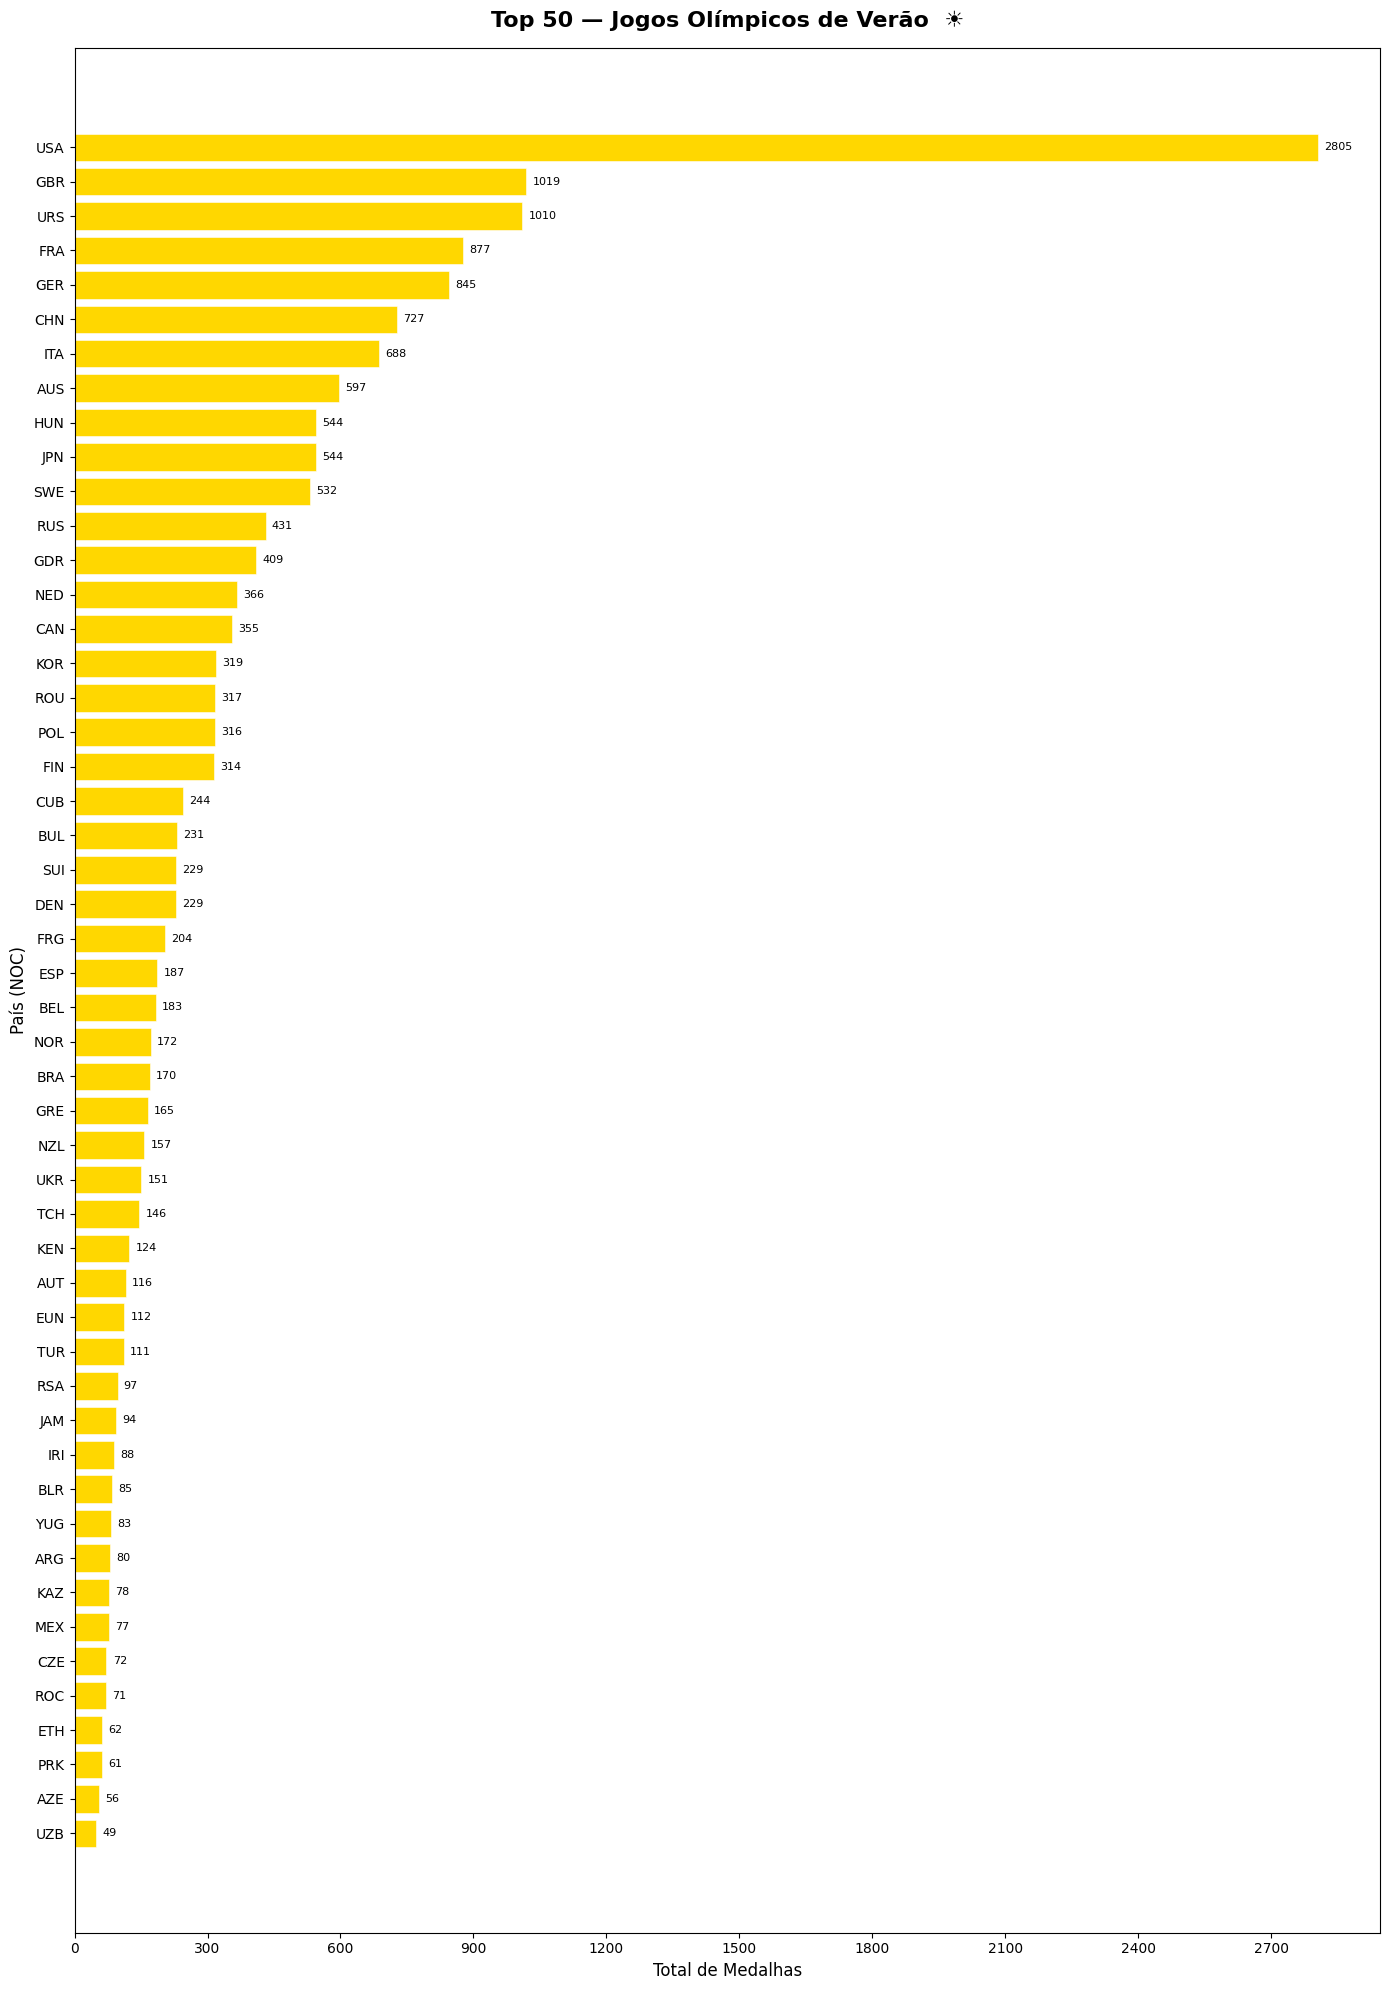

✅ Gráfico salvo: olympics-datalake/gold/analise_medalhas/top50_verao.png


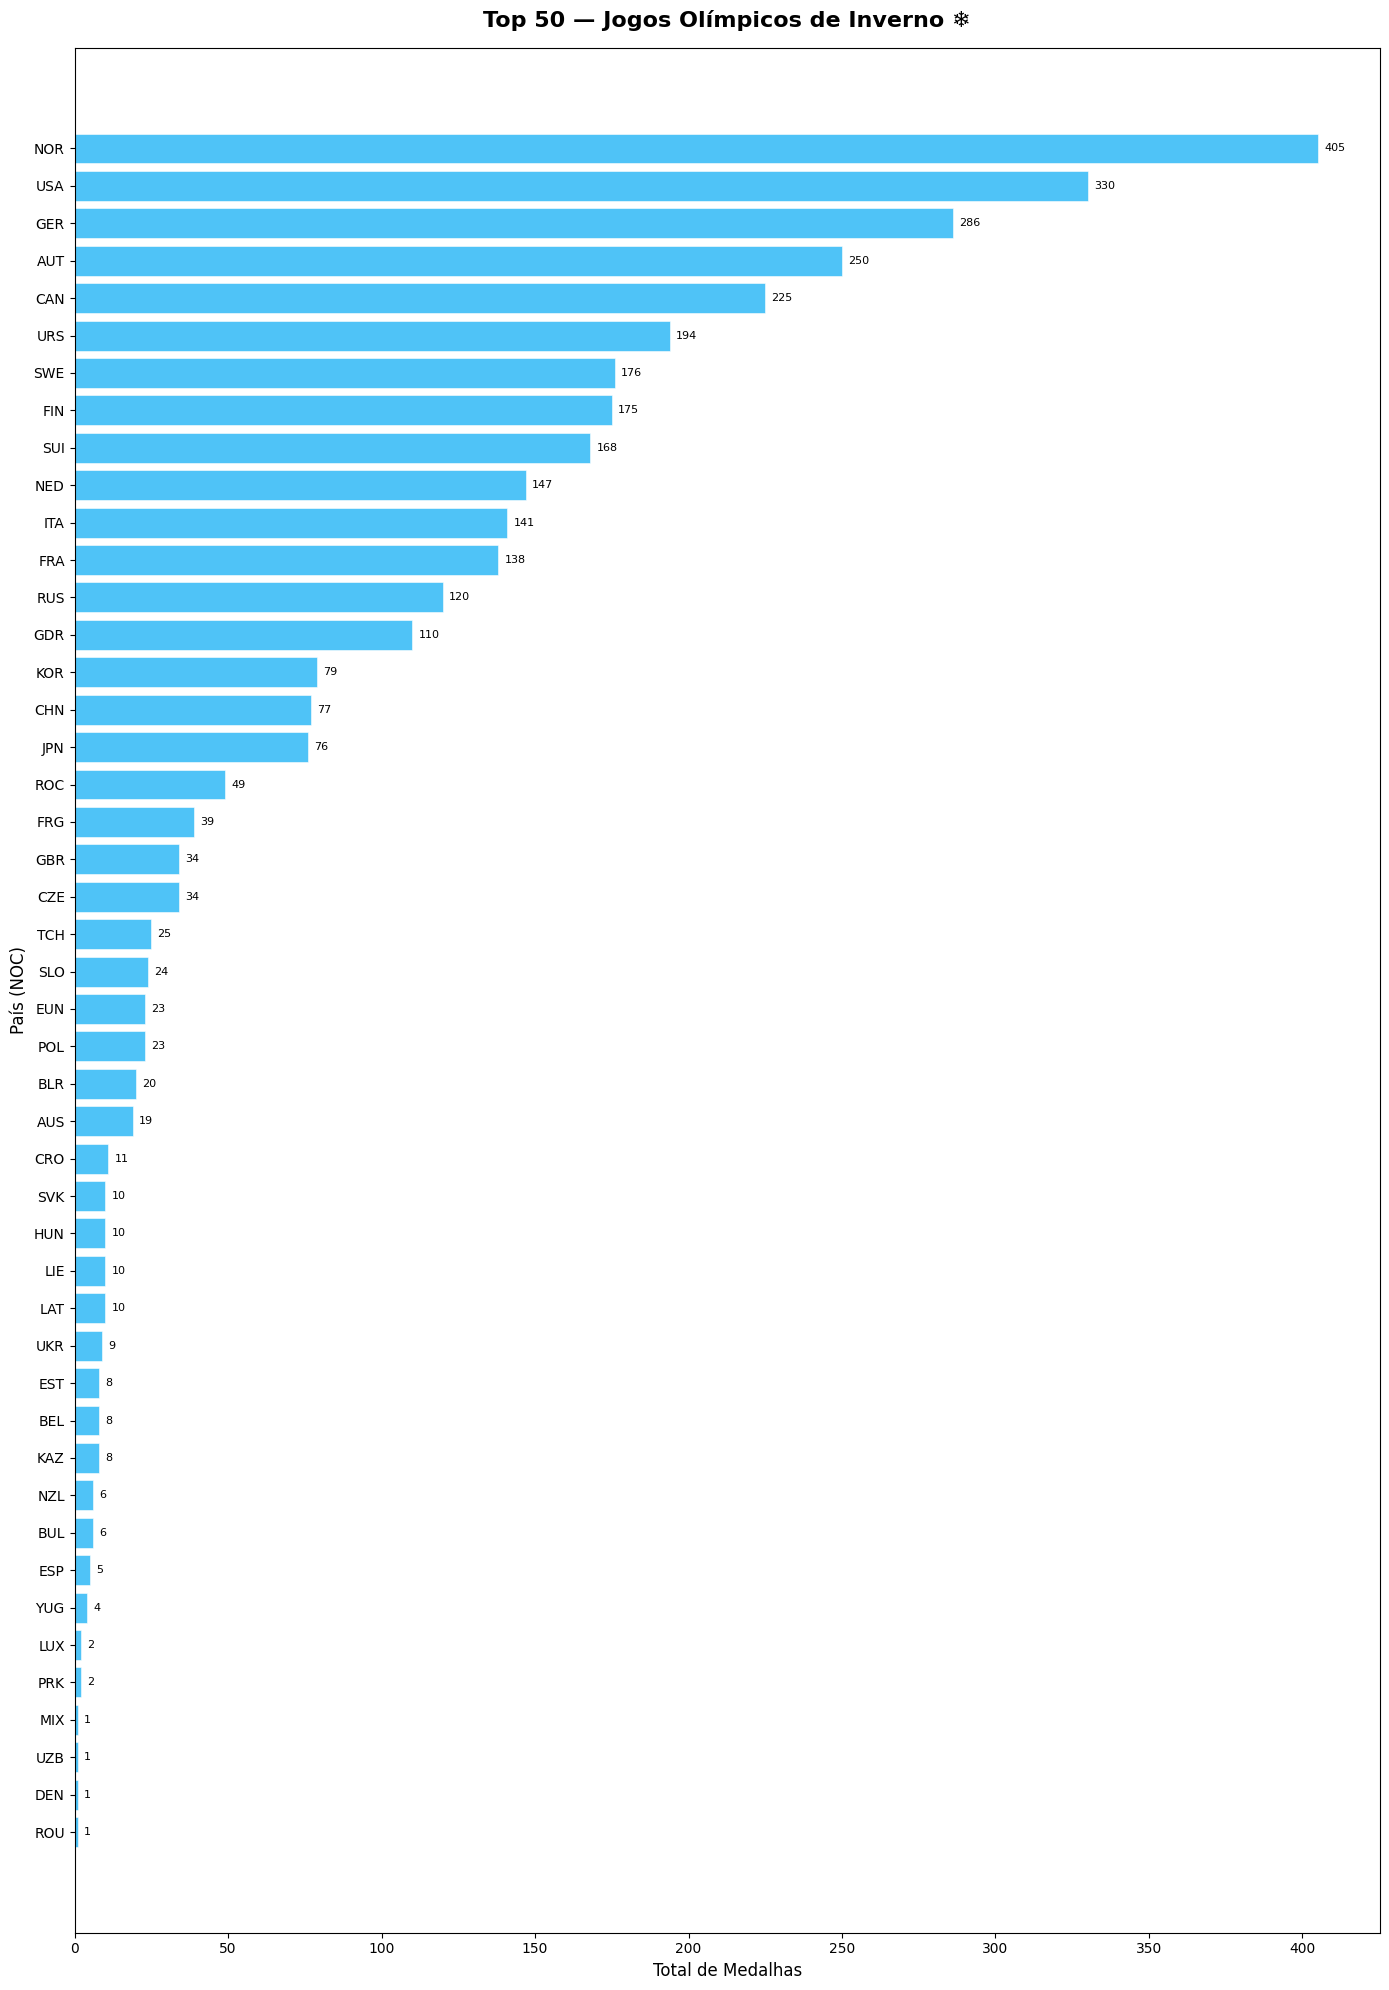

✅ Gráfico salvo: olympics-datalake/gold/analise_medalhas/top50_inverno.png


/tmp/ipykernel_661/1798246328.py:22: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_661/1798246328.py:24: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig(caminho_grafico, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


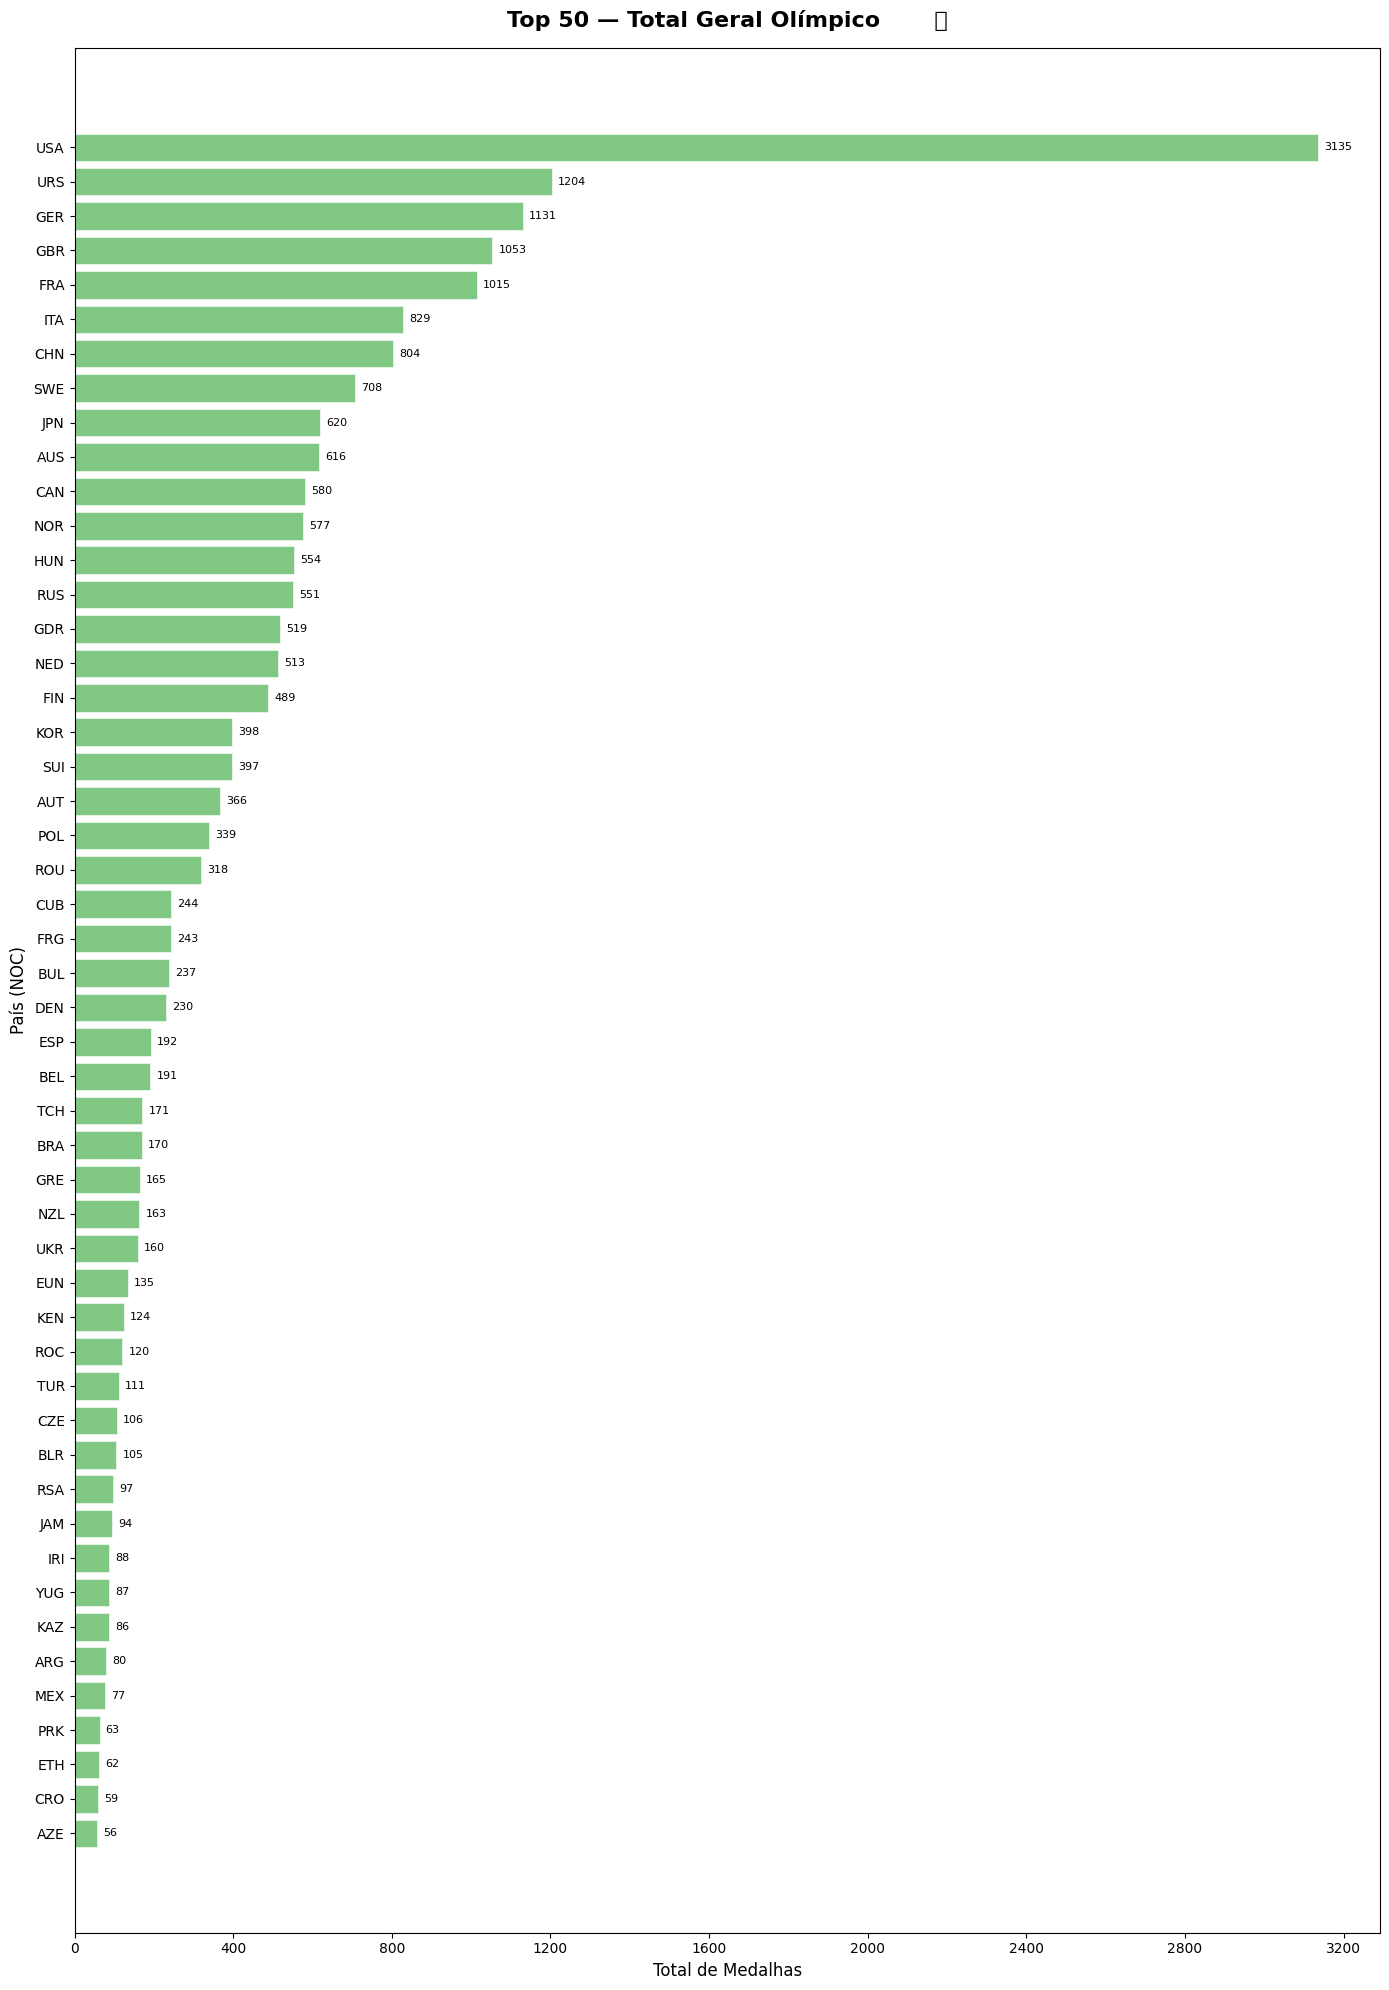

✅ Gráfico salvo: olympics-datalake/gold/analise_medalhas/top50_total.png


In [ ]:
# -------------------------------------------------------
# 5.4 Gráficos Top 50 — barras horizontais
# -------------------------------------------------------
def plot_top50(df_table, titulo, cor, nome_arquivo):
    top50 = df_table.head(50).copy().iloc[::-1]  # inverte: maior no topo

    fig, ax = plt.subplots(figsize=(14, 20))
    bars = ax.barh(top50['NOC'], top50['Total'], color=cor, edgecolor='white', linewidth=0.4)

    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Total de Medalhas', fontsize=12)
    ax.set_ylabel('País (NOC)', fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Rótulos no final de cada barra
    max_val = top50['Total'].max()
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max_val * 0.005, bar.get_y() + bar.get_height() / 2,
                str(int(w)), va='center', ha='left', fontsize=8)

    plt.tight_layout()
    caminho_grafico = GOLD / nome_arquivo
    plt.savefig(caminho_grafico, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Gráfico salvo: {caminho_grafico}")
    return caminho_grafico

plot_summer = plot_top50(tbl_summer, 'Top 50 — Jogos Olímpicos de Verão  ☀️',  '#FFD700', 'top50_verao.png')
plot_winter = plot_top50(tbl_winter, 'Top 50 — Jogos Olímpicos de Inverno ❄️', '#4FC3F7', 'top50_inverno.png')
plot_total  = plot_top50(tbl_total,  'Top 50 — Total Geral Olímpico       🏅',  '#81C784', 'top50_total.png')

In [ ]:
# -------------------------------------------------------
# 5.5 Salvar CSVs finais na gold/
# -------------------------------------------------------
# Quadro completo no formato Wikipédia
caminho_quadro_csv = GOLD / "medalhas_summary.csv"
df_quadro.to_csv(caminho_quadro_csv, index=False)

# Tabelas individuais
tbl_summer.to_csv(GOLD / "medalhas_verao.csv",   index=False)
tbl_winter.to_csv(GOLD / "medalhas_inverno.csv", index=False)
tbl_total.to_csv( GOLD / "medalhas_total.csv",   index=False)

print("✅ Datasets salvos na gold/analise_medalhas/:")
for f in GOLD.iterdir():
    print(f"   {f.name}")

✅ Datasets salvos na gold/analise_medalhas/:
   medalhas_verao.csv
   top50_inverno.png
   top50_verao.png
   medalhas_inverno.csv
   medalhas_total.csv
   top50_total.png
   medalhas_summary.csv


In [ ]:
# -------------------------------------------------------
# 5.6 Metadados da camada Gold
# -------------------------------------------------------
meta_gold = {
    "nome_dataset": "quadro_medalhas_olimpicas",
    "descricao": "Quadro consolidado de medalhas olímpicas por país, com separação por Jogos de Verão, Jogos de Inverno e Total Geral. Compatível com o quadro oficial publicado na Wikipédia.",
    "fontes_origem": [
        "bronze/medalhas_1896_2024.parquet"
    ],
    "operacao": "Agregação por NOC com groupby + join entre Summer e Winter",
    "campos_principais": [
        {"nome": "NOC",      "descricao": "Código do país (3 letras)"},
        {"nome": "S_Gold",   "descricao": "Ouros nos Jogos de Verão"},
        {"nome": "S_Silver", "descricao": "Pratas nos Jogos de Verão"},
        {"nome": "S_Bronze", "descricao": "Bronzes nos Jogos de Verão"},
        {"nome": "S_Total",  "descricao": "Total nos Jogos de Verão"},
        {"nome": "W_Gold",   "descricao": "Ouros nos Jogos de Inverno"},
        {"nome": "W_Silver", "descricao": "Pratas nos Jogos de Inverno"},
        {"nome": "W_Bronze", "descricao": "Bronzes nos Jogos de Inverno"},
        {"nome": "W_Total",  "descricao": "Total nos Jogos de Inverno"},
        {"nome": "T_Gold",   "descricao": "Total geral de ouros"},
        {"nome": "T_Silver", "descricao": "Total geral de pratas"},
        {"nome": "T_Bronze", "descricao": "Total geral de bronzes"},
        {"nome": "T_Total",  "descricao": "Total geral de medalhas"}
    ],
    "arquivos_gerados": [
        "medalhas_summary.csv  — quadro completo (formato Wikipédia)",
        "medalhas_verao.csv    — ranking por Jogos de Verão (Top 50)",
        "medalhas_inverno.csv  — ranking por Jogos de Inverno (Top 50)",
        "medalhas_total.csv    — ranking geral (Top 50)",
        "top50_verao.png       — gráfico de barras Top 50 Verão",
        "top50_inverno.png     — gráfico de barras Top 50 Inverno",
        "top50_total.png       — gráfico de barras Top 50 Total"
    ],
    "periodo_coberto": "1896–2024",
    "data_processamento": str(date.today()),
    "camada": "gold",
    "versao": "1.0",
    "observacoes": "Ordenação: Total Geral decrescente, desempate por Ouro e Prata."
}

caminho_meta_gold = GOLD / "metadata.json"
with open(caminho_meta_gold, "w", encoding="utf-8") as f:
    json.dump(meta_gold, f, ensure_ascii=False, indent=4)

print(f"✅ Metadados gold salvos: {caminho_meta_gold}")

✅ Metadados gold salvos: olympics-datalake/gold/analise_medalhas/metadata.json


## 6. README.md e metadata_schema.json

In [ ]:
# -------------------------------------------------------
# 6.1 README.md
# -------------------------------------------------------
readme_content = """# 🏅 Olympics Data Lake

Data Lake local com dados históricos dos Jogos Olímpicos (1896–2024).

## Objetivo

Consolidar o quadro de medalhas olímpicas por país, com separação entre
Jogos de Verão e Jogos de Inverno, a partir de fontes públicas.

## Fontes

| Arquivo | Fonte | Período |
|---------|-------|---------|
| `olympics_historico.csv` | Base dos Dados / Olympedia | 1896–2022 |
| `olympics_paris2024.csv` | Kaggle — Paris 2024 | 2024 |

## Estrutura

```
olympics-datalake/
├── README.md
├── metadata_schema.json
├── raw/                        # Dados brutos originais
│   ├── olympics_historico.csv
│   ├── olympics_historico.json
│   ├── olympics_paris2024.csv
│   └── olympics_paris2024.json
├── bronze/                     # Dados padronizados e integrados
│   ├── olympics_historico.parquet
│   ├── olympics_paris2024.parquet
│   ├── medalhas_1896_2024.csv
│   ├── medalhas_1896_2024.parquet
│   └── medalhas_1896_2024.json
└── gold/
    └── analise_medalhas/       # Quadro final + gráficos
        ├── medalhas_summary.csv
        ├── medalhas_verao.csv
        ├── medalhas_inverno.csv
        ├── medalhas_total.csv
        ├── top50_verao.png
        ├── top50_inverno.png
        ├── top50_total.png
        └── metadata.json
```

## Pipeline

```
raw/ (CSV brutos)
  └─► bronze/ (padronização + Parquet + JOIN entre fontes)
        └─► gold/ (agregação final + visualizações)
```

## Aluno

Daniel Nazário Oliveira de Souza — Sistemas de Informação, UEA
Professor: Luis Cueves Rodriguez
"""

with open(DATALAKE_ROOT / "README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("✅ README.md criado")

✅ README.md criado


In [ ]:
# -------------------------------------------------------
# 6.2 metadata_schema.json — esquema técnico global
# -------------------------------------------------------
metadata_schema = {
    "schema_version": "1.0",
    "descricao": "Esquema padrão de metadados adotado neste Data Lake. Todo arquivo de dados deve possuir um .json correspondente com estes campos.",
    "campos_obrigatorios": [
        {"campo": "nome_dataset",       "tipo": "string",  "descricao": "Identificador único do dataset"},
        {"campo": "descricao",          "tipo": "string",  "descricao": "Descrição legível do conteúdo"},
        {"campo": "fonte",              "tipo": "string",  "descricao": "URL ou referência da origem dos dados"},
        {"campo": "campos_principais",  "tipo": "array",   "descricao": "Lista de objetos com nome, tipo e descricao de cada coluna"},
        {"campo": "data_coleta",        "tipo": "string",  "descricao": "Data de coleta ou processamento (YYYY-MM-DD)"},
        {"campo": "formato",            "tipo": "string",  "descricao": "Formato do arquivo (CSV, Parquet, JSON...)"},
        {"campo": "camada",             "tipo": "string",  "descricao": "Camada do Data Lake: raw, bronze ou gold"},
        {"campo": "versao",             "tipo": "string",  "descricao": "Versão do dataset"}
    ],
    "campos_opcionais": [
        {"campo": "fontes_origem",      "descricao": "Datasets de origem (para camadas bronze e gold)"},
        {"campo": "operacao",           "descricao": "Transformação aplicada (JOIN, GROUP BY, filtro...)"},
        {"campo": "periodo_coberto",    "descricao": "Intervalo temporal dos dados"},
        {"campo": "quantidade_linhas",  "descricao": "Número de registros no dataset"},
        {"campo": "observacoes",        "descricao": "Notas adicionais relevantes"}
    ],
    "camadas": {
        "raw":    "Dados brutos sem transformação, exatamente como coletados na fonte",
        "bronze": "Dados padronizados, tipados e integrados entre fontes (Parquet)",
        "gold":   "Dados prontos para análise e visualização, agregados e enriquecidos"
    }
}

with open(DATALAKE_ROOT / "metadata_schema.json", "w", encoding="utf-8") as f:
    json.dump(metadata_schema, f, ensure_ascii=False, indent=4)

print("✅ metadata_schema.json criado")

✅ metadata_schema.json criado


## 7. Visão Final da Estrutura do Data Lake

In [ ]:
# -------------------------------------------------------
# 7.1 Listar todos os arquivos criados
# -------------------------------------------------------
print("📁 Estrutura final do Data Lake:\n")
for root, dirs, files_list in os.walk(DATALAKE_ROOT):
    # Ocultar pastas vazias
    nivel = root.replace(str(DATALAKE_ROOT), '').count(os.sep)
    indent = '│   ' * nivel + '├── '
    print(f"{indent}{os.path.basename(root)}/")
    subindent = '│   ' * (nivel + 1) + '├── '
    for filename in sorted(files_list):
        caminho_f = Path(root) / filename
        tamanho = os.path.getsize(caminho_f)
        unidade = 'KB' if tamanho >= 1024 else 'B'
        tamanho_fmt = f"{tamanho//1024} {unidade}" if tamanho >= 1024 else f"{tamanho} B"
        print(f"{subindent}{filename}  ({tamanho_fmt})")

📁 Estrutura final do Data Lake:

├── olympics-datalake/
│   ├── README.md  (1 KB)
│   ├── metadata_schema.json  (2 KB)
│   ├── bronze/
│   │   ├── medalhas_1896_2024.csv  (108 KB)
│   │   ├── medalhas_1896_2024.json  (2 KB)
│   │   ├── medalhas_1896_2024.parquet  (21 KB)
│   │   ├── olympics_historico.parquet  (20 KB)
│   │   ├── olympics_paris2024.parquet  (7 KB)
│   ├── raw/
│   │   ├── olympics_historico.csv  (90 KB)
│   │   ├── olympics_historico.json  (1 KB)
│   │   ├── olympics_paris2024.csv  (2 KB)
│   │   ├── olympics_paris2024.json  (1 KB)
│   ├── gold/
│   │   ├── analise_modalidades/
│   │   ├── analise_medalhas/
│   │   │   ├── medalhas_inverno.csv  (697 B)
│   │   │   ├── medalhas_summary.csv  (5 KB)
│   │   │   ├── medalhas_total.csv  (937 B)
│   │   │   ├── medalhas_verao.csv  (919 B)
│   │   │   ├── metadata.json  (2 KB)
│   │   │   ├── top50_inverno.png  (131 KB)
│   │   │   ├── top50_total.png  (151 KB)
│   │   │   ├── top50_verao.png  (151 KB)
│   │   ├── analise_gen

In [ ]:
# -------------------------------------------------------
# 7.2 Compactar o Data Lake para download / envio ao GitHub
# -------------------------------------------------------
shutil.make_archive("olympics-datalake", 'zip', ".", "olympics-datalake")
print("✅ Arquivo olympics-datalake.zip gerado para download!")

# Download automático no Colab
from google.colab import files
files.download("olympics-datalake.zip")

✅ Arquivo olympics-datalake.zip gerado para download!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>